# Same table operations. Different dataframe engines.

## Pandas • Polars • PySpark

We will preview two common dataframe operations, then run one equivalent **group → filter → join → sort** query in every available engine.

> The dataset is only a test case. The lesson is how similar-looking dataframe instructions reach different execution engines.

By the end, you should be able to explain why API syntax alone does not determine performance or scale—and choose an appropriate engine for a workload.

### Today’s route

| Time | Framework focus |
|---:|---|
| 0–3 | One table and three queries |
| 3–11 | Pandas: local, eager dataframe work |
| 11–24 | Polars: eager vs lazy and optimization |
| 24–34 | PySpark: plans, partitions, and distribution |
| 34–41 | Equivalent-result benchmark |
| 41–45 | Framework choice and recap |

Watch for three things: **where work runs, when it runs, and how the engine plans it**.

In [1]:
from pathlib import Path
import os, shutil, time, warnings

import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Keep unexpected warnings visible during class; suppress only known seaborn deprecations.
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")
sns.set_theme(style="whitegrid", context="talk")
palette = sns.color_palette("colorblind", 4)
FRAMEWORK_COLORS = dict(
    zip(["Pandas", "Polars Eager", "Polars Lazy", "PySpark"], palette)
)

FAST_DEMO = True
MIN_RATINGS = 1_000
TOP_N = 10

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RATINGS_PATH = (
    ROOT
    / "data/parquet"
    / ("ratings_1m.parquet" if FAST_DEMO else "ratings_32m.parquet")
)
MOVIES_PATH = ROOT / "data/parquet/movies.parquet"
missing = [path for path in (RATINGS_PATH, MOVIES_PATH) if not path.exists()]
assert not missing, f"Missing {', '.join(map(str, missing))}; run `make data`."

# Make a Homebrew OpenJDK 17 installation visible to local PySpark.
for java_home in [
    Path("/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"),
    Path("/usr/local/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"),
]:
    if "JAVA_HOME" not in os.environ and java_home.exists():
        os.environ["JAVA_HOME"] = str(java_home)
os.environ.setdefault("SPARK_LOCAL_IP", "127.0.0.1")
java_status = (
    "ready"
    if os.environ.get("JAVA_HOME") or shutil.which("java")
    else "not found (Spark will be skipped)"
)
print(f"Data: {RATINGS_PATH.name} | threshold: {MIN_RATINGS:,}")
print(f"Pandas {pd.__version__} | Polars {pl.__version__} | Java {java_status}")

Data: ratings_1m.parquet | threshold: 1,000
Pandas 3.0.5 | Polars 1.44.1 | Java ready


## 1. The test table—in 60 seconds

MovieLens gives us a familiar table large enough to exercise each engine.

| userId | movieId | rating | timestamp |
|---:|---:|---:|---:|
| 1 | 296 | 5.0 | … |
| 1 | 306 | 3.5 | … |

A row means **one person rated one movie**. That is all the domain knowledge we need.

In [2]:
ratings = pd.read_parquet(RATINGS_PATH)
movies = pd.read_parquet(MOVIES_PATH)

print(
    f"{len(ratings):,} ratings • {ratings['userId'].nunique():,} users • {movies['movieId'].nunique():,} movies"
)
display(ratings[["userId", "movieId", "rating"]].head(5).style.hide(axis="index"))

1,000,000 ratings • 167,203 users • 87,585 movies


userId,movieId,rating
163692,201749,4.000000
63885,914,3.000000
197767,593,3.500000
140531,1291,4.000000
159429,265148,2.500000


## Syntax preview 1 — select and filter rows

**Question:** Which ratings are 4.5 stars or higher?

We will execute this preview in Pandas, then compare how the same request is expressed elsewhere. The fully equivalent cross-engine run begins with Query 3.

In [3]:
high_ratings = ratings.loc[
    ratings["rating"] >= 4.5,
    ["userId", "movieId", "rating"],
]
print(f"Pandas returned {len(high_ratings):,} matching rows immediately.")
display(high_ratings.head(5).style.hide(axis="index"))

Pandas returned 236,115 matching rows immediately.


userId,movieId,rating
121305,1214,5.000000
187312,1186,4.500000
14147,953,4.500000
80722,47,4.500000
109258,1213,4.500000


### Query 1 looks familiar in every framework

```python
# Pandas
ratings.loc[ratings["rating"] >= 4.5, ["userId", "movieId", "rating"]]

# Polars
ratings.filter(pl.col("rating") >= 4.5).select("userId", "movieId", "rating")

# PySpark
ratings.filter(F.col("rating") >= 4.5).select("userId", "movieId", "rating")
```

The request is the same: **filter rows, then choose columns**.

The important difference comes next: does the framework execute now, build a plan, use native threads, or schedule partitioned tasks?

## Syntax preview 2 — group and aggregate

**Question:** For each movie, what are the average rating and number of ratings?

```text
ratings → group by movieId → average(rating) + count(rows)
```

We will execute this preview in Pandas. Before running it, predict: how many output rows can a million input rows produce? The engine must bring related rows together, so this operation also prepares us to discuss partitions and query plans.

In [4]:
movie_stats = (
    ratings.groupby("movieId")["rating"]
    .agg(average_rating="mean", rating_count="count")
    .reset_index()
)
print(f"One million input rows became {len(movie_stats):,} movie groups.")
display(
    movie_stats.head(8)
    .style.format({"average_rating": "{:.2f}", "rating_count": "{:,}"})
    .hide(axis="index")
)

One million input rows became 27,802 movie groups.


movieId,average_rating,rating_count
1,3.90,"2,171"
2,3.25,891
3,3.12,423
4,2.76,99
5,3.02,396
6,3.86,932
7,3.40,425
8,3.17,49


### Query 2: same intent, different APIs

```python
# Pandas
ratings.groupby("movieId").agg(average_rating=("rating", "mean"), rating_count=("rating", "count"))

# Polars
ratings.group_by("movieId").agg(pl.col("rating").mean(), pl.len())

# PySpark
ratings.groupBy("movieId").agg(F.avg("rating"), F.count("*"))
```

Do not memorize the punctuation. Notice that every API communicates the same operations: **group, average, count**.

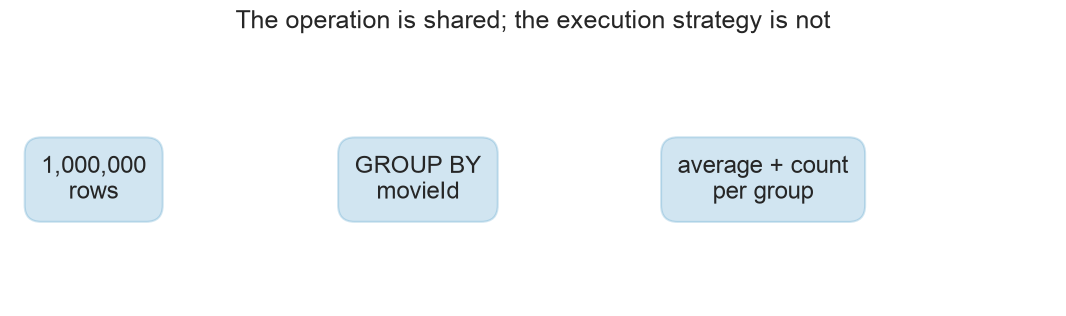

In [5]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.axis("off")
steps = [
    (0.08, "1,000,000\nrows"),
    (0.39, "GROUP BY\nmovieId"),
    (0.72, "average + count\nper group"),
]
for x, label in steps:
    ax.text(
        x,
        0.5,
        label,
        ha="center",
        va="center",
        fontsize=17,
        bbox=dict(
            boxstyle="round,pad=.7",
            facecolor=palette[0],
            alpha=0.18,
            edgecolor=palette[0],
        ),
    )
for start, end in [(0.18, 0.29), (0.51, 0.62)]:
    ax.annotate(
        "", xy=(end, 0.5), xytext=(start, 0.5), arrowprops=dict(arrowstyle="->", lw=2)
    )
ax.set_title("The operation is shared; the execution strategy is not", pad=18)
plt.tight_layout()
plt.show()

## 2. Pandas — local and eager

## Query 3: group → filter → join → sort

This combines the common dataframe operations into the one workload we will benchmark.

```text
Python instructions
        ↓
Pandas executes locally as each result is requested
        ↓
native / vectorized dataframe operations
        ↓
result in laptop memory
```

Pandas is **not** simply running a Python loop over one million rows. Its mental model is still straightforward: ask for a dataframe operation and receive its result.

In [6]:
# Live timings use one cold, end-to-end run: read files, execute, and materialize the result.
pandas_start = time.perf_counter()
pandas_ratings = pd.read_parquet(RATINGS_PATH, columns=["movieId", "rating"])
pandas_movies = pd.read_parquet(MOVIES_PATH, columns=["movieId", "title"])
pandas_result = (
    pandas_ratings.groupby("movieId")
    .agg(average_rating=("rating", "mean"), rating_count=("rating", "count"))
    .query("rating_count >= @MIN_RATINGS")
    .reset_index()
    .merge(pandas_movies, on="movieId")
    .sort_values(
        ["average_rating", "rating_count", "movieId"], ascending=[False, False, True]
    )
    .reset_index(drop=True)
)
pandas_runtime = time.perf_counter() - pandas_start
LIVE_ROWS = len(pandas_ratings)

display(
    pandas_result.head(TOP_N)[["title", "average_rating", "rating_count"]]
    .style.format({"average_rating": "{:.2f}", "rating_count": "{:,}"})
    .hide(axis="index")
)

title,average_rating,rating_count
"Shawshank Redemption, The (1994)",4.38,"3,212"
"Godfather, The (1972)",4.31,"2,000"
"Godfather: Part II, The (1974)",4.27,"1,332"
Schindler's List (1993),4.27,"2,337"
"Usual Suspects, The (1995)",4.24,"2,068"
Spirited Away (Sen to Chihiro no kamikakushi) (2001),4.23,"1,041"
One Flew Over the Cuckoo's Nest (1975),4.22,"1,371"
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964),4.21,"1,008"
Fight Club (1999),4.20,"2,393"
Pulp Fiction (1994),4.20,"2,989"


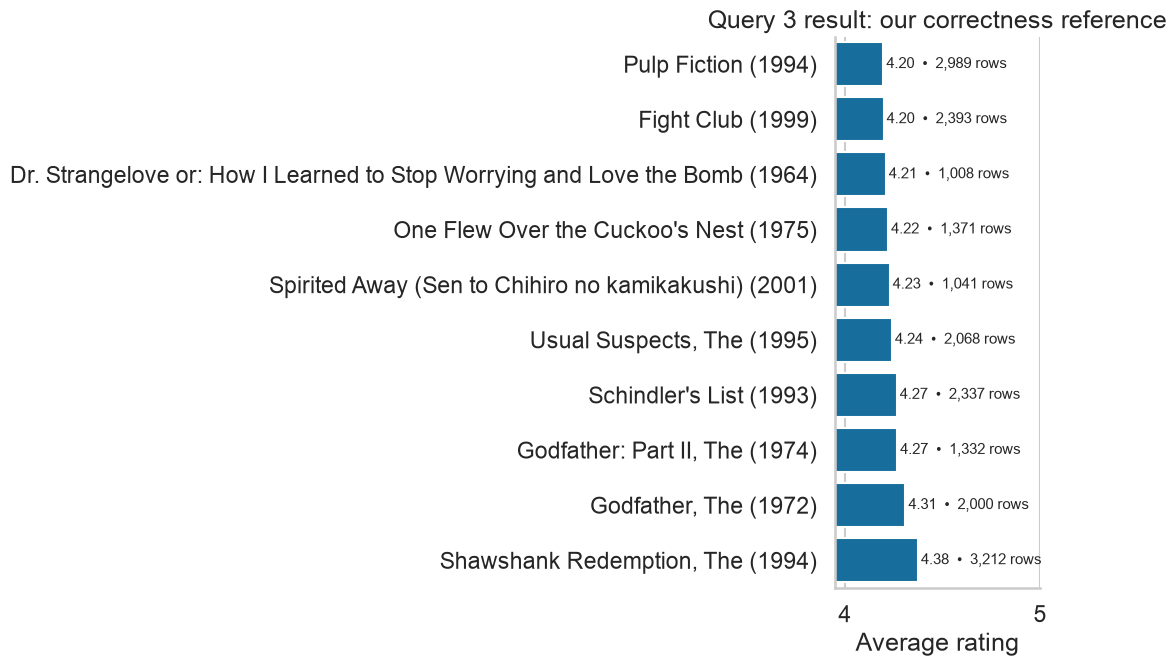

In [7]:
top_movies = pandas_result.head(TOP_N).sort_values("average_rating")
fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(
    data=top_movies,
    x="average_rating",
    y="title",
    color=FRAMEWORK_COLORS["Pandas"],
    ax=ax,
)
ax.set(
    title="Query 3 result: our correctness reference",
    xlabel="Average rating",
    ylabel="",
)
ax.set_xlim(max(0, top_movies.average_rating.min() - 0.25), 5)
for bar, (_, row) in zip(ax.patches, top_movies.iterrows()):
    ax.text(
        row.average_rating + 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{row.average_rating:.2f}  •  {row.rating_count:,.0f} rows",
        va="center",
        fontsize=11,
    )
sns.despine()
plt.tight_layout()
plt.show()

## 3. Polars — native, parallel, and optionally lazy

Query 3 barely changes, but the execution options do.

- **Eager Polars:** read now and return each requested result.
- **Lazy Polars:** describe the entire query, optimize it, then execute.
- **Both:** send expression work into the same native Polars engine.

The proper term for improving the whole plan is **query optimization**.

In [8]:
polars_start = time.perf_counter()
pl_ratings = pl.read_parquet(RATINGS_PATH, columns=["movieId", "rating"])
pl_movies = pl.read_parquet(MOVIES_PATH, columns=["movieId", "title"])
polars_eager_result = (
    pl_ratings.group_by("movieId")
    .agg(
        pl.col("rating").mean().alias("average_rating"), pl.len().alias("rating_count")
    )
    .filter(pl.col("rating_count") >= MIN_RATINGS)
    .join(pl_movies, on="movieId")
    .sort(["average_rating", "rating_count", "movieId"], descending=[True, True, False])
)
polars_eager_runtime = time.perf_counter() - polars_start
polars_eager_result.head(TOP_N)

movieId,average_rating,rating_count,title
i32,f32,u32,str
318,4.375311,3212,"""Shawshank Redemption, The (199…"
858,4.31075,2000,"""Godfather, The (1972)"""
1221,4.268394,1332,"""Godfather: Part II, The (1974)"""
527,4.266581,2337,"""Schindler's List (1993)"""
50,4.242021,2068,"""Usual Suspects, The (1995)"""
5618,4.230067,1041,"""Spirited Away (Sen to Chihiro …"
1193,4.222101,1371,"""One Flew Over the Cuckoo's Nes…"
750,4.210318,1008,"""Dr. Strangelove or: How I Lear…"
2959,4.199122,2393,"""Fight Club (1999)"""


In [9]:
lazy_query = (
    pl.scan_parquet(RATINGS_PATH)
    .group_by("movieId")
    .agg(
        pl.col("rating").mean().alias("average_rating"), pl.len().alias("rating_count")
    )
    .filter(pl.col("rating_count") >= MIN_RATINGS)
    .join(pl.scan_parquet(MOVIES_PATH).select("movieId", "title"), on="movieId")
    .sort(["average_rating", "rating_count", "movieId"], descending=[True, True, False])
)
polars_lazy_start = time.perf_counter()
polars_lazy_result = lazy_query.collect()
polars_lazy_runtime = time.perf_counter() - polars_lazy_start
print("The query runs only when collect() is called.")
polars_lazy_result.head(TOP_N)

The query runs only when collect() is called.


movieId,average_rating,rating_count,title
i32,f32,u32,str
318,4.375311,3212,"""Shawshank Redemption, The (199…"
858,4.31075,2000,"""Godfather, The (1972)"""
1221,4.268394,1332,"""Godfather: Part II, The (1974)"""
527,4.266581,2337,"""Schindler's List (1993)"""
50,4.242021,2068,"""Usual Suspects, The (1995)"""
5618,4.230067,1041,"""Spirited Away (Sen to Chihiro …"
1193,4.222101,1371,"""One Flew Over the Cuckoo's Nes…"
750,4.210318,1008,"""Dr. Strangelove or: How I Lear…"
2959,4.199122,2393,"""Fight Club (1999)"""


### Eager vs lazy: when does work happen?

Before revealing the answer, ask: **Did `scan_parquet` read the file? Which call finally executes the lazy query?**

```text
EAGER                              POLARS LAZY

read                               describe read
 ↓                                      ↓
group → produce result             describe group
 ↓                                      ↓
filter → produce result            describe filter + join + sort
                                        ↓
                                  optimize whole plan
                                        ↓
                                     execute at collect()
```

Lazy does not mean “never.” It means **wait until the engine can see the whole job**.

### Two common improvements

**Projection pushdown — read only needed columns**

```text
Original: userId | movieId | rating | timestamp
Needed:            movieId | rating

Before: read everything → discard two columns
After:  identify need → read only what matters
```

**Predicate pushdown — remove unneeded rows early**

> If we already know which rows we do not need, why carry them through later work?

Polars’ full text plan is available below, but the teaching point is just the scan, selected columns, aggregation, filter, join, and sort.

In [10]:
plan_lines = lazy_query.explain(optimized=True).splitlines()
print("\n".join(plan_lines[:18]))
print("\n… plan shortened for projection …" if len(plan_lines) > 18 else "")

SORT BY [descending: [true, true, false]] [col("average_rating"), col("rating_count"), col("movieId")]
  INNER JOIN:
  LEFT PLAN ON: [col("movieId")]
    FILTER col("rating_count") >= 1000
    FROM
      AGGREGATE[maintain_order: false]
        [col("rating").mean().alias("average_rating"), len().alias("rating_count")] BY [col("movieId")]
        FROM
        Parquet SCAN [/Users/kedarvaidya/Downloads/data-processing-frameworks-demo/data/parquet/ratings_1m.parquet]
        PROJECT 2/4 COLUMNS
        ESTIMATED ROWS: 1000000
  RIGHT PLAN ON: [col("movieId")]
    Parquet SCAN [/Users/kedarvaidya/Downloads/data-processing-frameworks-demo/data/parquet/movies.parquet]
    PROJECT 2/3 COLUMNS
    ESTIMATED ROWS: 87585
  END INNER JOIN



## 4. PySpark — plan once, execute across partitions

Query 3 still says group, filter, join, and sort. Spark’s defining difference is where that plan can run.

```text
                         DRIVER
                    builds query plan
                           │
               ┌───────────┼───────────┐
               ▼           ▼           ▼
          Executor 1  Executor 2  Executor 3
               │           │           │
           partition   partition   partition
```

```text
Python API → logical plan → Catalyst optimizer → physical tasks → executors
```

**Driver:** coordinates. **Executors:** process partitions. **Catalyst:** improves the plan.

Today every role runs on one laptop so we can use the API. Spark is designed for the same model to extend across machines.

> **Predict before running:** Will Spark beat the local engines on 1M rows? Which fixed costs does it pay before processing the first row?

In [11]:
spark_result = spark_result_pd = None
spark_runtime = spark = None
try:
    from pyspark.sql import SparkSession, functions as F

    spark_start = (
        time.perf_counter()
    )  # Cold, end-to-end: startup, reads, query, and collection.
    spark = (
        SparkSession.builder.master("local[*]")
        .appName("MovieLens TA demo")
        .config("spark.ui.enabled", "false")
        .config("spark.sql.shuffle.partitions", "8")
        .getOrCreate()
    )
    spark.sparkContext.setLogLevel("ERROR")
    sr, sm = spark.read.parquet(str(RATINGS_PATH)), spark.read.parquet(str(MOVIES_PATH))
    spark_result = (
        sr.groupBy("movieId")
        .agg(
            F.avg("rating").alias("average_rating"), F.count("*").alias("rating_count")
        )
        .filter(F.col("rating_count") >= MIN_RATINGS)
        .join(sm.select("movieId", "title"), "movieId")
        .orderBy(F.desc("average_rating"), F.desc("rating_count"), F.asc("movieId"))
    )
    spark_result_pd = spark_result.toPandas()
    spark_runtime = time.perf_counter() - spark_start
    display(spark_result_pd.head(TOP_N))
except Exception as exc:
    spark_result = spark_result_pd = None
    print(f"Spark skipped: {type(exc).__name__}: {exc}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/Users/kedarvaidya/Downloads/data-processing-frameworks-demo/.venv/lib/python3.13/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/08/27 13:00:36 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


/Users/kedarvaidya/Downloads/data-processing-frameworks-demo/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,movieId,average_rating,rating_count,title
0,318,4.375311,3212,"Shawshank Redemption, The (1994)"
1,858,4.310750,2000,"Godfather, The (1972)"
2,1221,4.268393,1332,"Godfather: Part II, The (1974)"
3,527,4.266581,2337,Schindler's List (1993)
4,50,4.242021,2068,"Usual Suspects, The (1995)"
5,5618,4.230067,1041,Spirited Away (Sen to Chihiro no kamikakushi) ...
6,1193,4.222101,1371,One Flew Over the Cuckoo's Nest (1975)
7,750,4.210317,1008,Dr. Strangelove or: How I Learned to Stop Worr...
8,2959,4.199122,2393,Fight Club (1999)
9,296,4.197892,2989,Pulp Fiction (1994)


### Why might Spark lose a laptop benchmark?

- Starting the JVM and Spark session costs time.
- Scheduling tasks costs time.
- One million rows fit comfortably on one laptop.
- Spark is built for workloads that may need many machines.

> A delivery truck may lose a race to a bicycle around one block. That does not make the truck useless.

In [12]:
if spark_result is not None:
    display(Markdown("""
**Plan to read aloud:** Parquet scan → partial aggregate → shuffle → final aggregate → join → sort

Spark also projects the required columns and uses adaptive execution. Run
`spark_result.explain("formatted")` after class to inspect the full physical plan.
"""))


**Plan to read aloud:** Parquet scan → partial aggregate → shuffle → final aggregate → join → sort

Spark also projects the required columns and uses adaptive execution. Run
`spark_result.explain("formatted")` after class to inspect the full physical plan.


## 5. Query 3 benchmark — equivalent work, explicit methodology

We compare the shared **read → group → filter → join → sort → materialize** pipeline.

Before comparing runtime, compare **answers**. A fast wrong answer is still wrong. The full automated validation lives in `benchmarks/validate.py`; class time only needs the status.

Two kinds of evidence follow:

- **Live demo:** one cold, end-to-end run from this notebook. It is useful for immediacy, not ranking.
- **Prepared benchmark:** median of three end-to-end runs from `benchmarks/benchmark.py`. These points form the scaling chart.

Keeping them separate avoids replacing repeatable measurements with noisy one-shot timings.

In [13]:
def comparable(frame):
    return (
        frame[["movieId", "average_rating", "rating_count"]]
        .sort_values("movieId")
        .reset_index(drop=True)
    )


pd.testing.assert_frame_equal(
    comparable(pandas_result),
    comparable(polars_eager_result.to_pandas()),
    check_dtype=False,
    atol=1e-6,
    rtol=1e-6,
)
pd.testing.assert_frame_equal(
    comparable(pandas_result),
    comparable(polars_lazy_result.to_pandas()),
    check_dtype=False,
    atol=1e-6,
    rtol=1e-6,
)
print("✓ Pandas matches Polars Eager\n✓ Pandas matches Polars Lazy")
if spark_result_pd is not None:
    pd.testing.assert_frame_equal(
        comparable(pandas_result),
        comparable(spark_result_pd),
        check_dtype=False,
        atol=1e-6,
        rtol=1e-6,
    )
    print("✓ PySpark matches")

✓ Pandas matches Polars Eager
✓ Pandas matches Polars Lazy
✓ PySpark matches


Live demo — one cold, end-to-end run (do not treat as a ranking)


framework,rows,runtime_seconds
Pandas,"1,000,000",0.028
Polars Eager,"1,000,000",0.084
Polars Lazy,"1,000,000",0.009
PySpark,"1,000,000",4.742


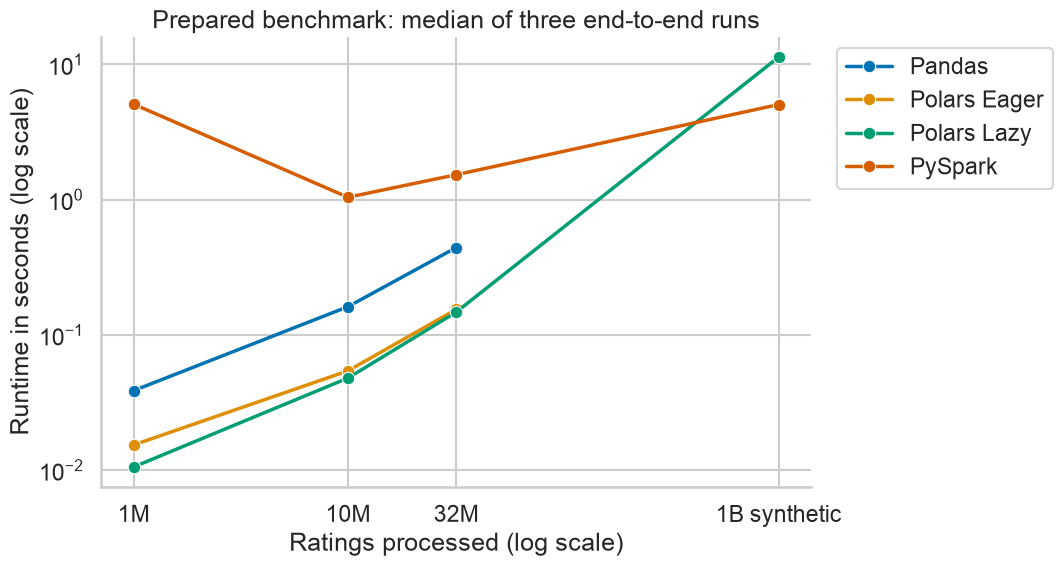

In [14]:
prepared = pd.read_csv(ROOT / "results/benchmark_results.csv")

# Show this session separately; never overwrite repeatable benchmark results with one-shot timings.
live = pd.DataFrame(
    [
        {"framework": framework, "rows": LIVE_ROWS, "runtime_seconds": runtime}
        for framework, runtime in {
            "Pandas": pandas_runtime,
            "Polars Eager": polars_eager_runtime,
            "Polars Lazy": polars_lazy_runtime,
            "PySpark": spark_runtime,
        }.items()
        if runtime is not None
    ]
)
print("Live demo — one cold, end-to-end run (do not treat as a ranking)")
display(
    live.style.format({"rows": "{:,}", "runtime_seconds": "{:.3f}"}).hide(axis="index")
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.lineplot(
    data=prepared,
    x="rows",
    y="runtime_seconds",
    hue="framework",
    marker="o",
    palette=FRAMEWORK_COLORS,
    linewidth=2.5,
    markersize=9,
    ax=ax,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set(
    title="Prepared benchmark: median of three end-to-end runs",
    xlabel="Ratings processed (log scale)",
    ylabel="Runtime in seconds (log scale)",
)
ax.set_xticks(
    [1_000_000, 10_000_000, 32_000_000, 1_024_006_528],
    labels=["1M", "10M", "32M", "1B synthetic"],
)
ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
sns.despine()
plt.tight_layout()
plt.show()

> **These prepared measurements describe this machine and this workload. They are not universal rankings.**

The **1B synthetic** point repeats MovieLens 32M as 32 Parquet partitions. It tests scale—not new movie behavior.

Using the median of three end-to-end runs on this 24 GB laptop:

- through 32M rows, Spark startup and scheduling dominate;
- at roughly 1B rows, local PySpark completed in **5.05s** versus **11.32s** for lazy Polars;
- Pandas and eager Polars were intentionally not run at 1B to avoid an unsafe memory experiment.

Hardware, caching, warm-up, partitioning, and optimizer behavior can move the crossover. Spark’s durable advantage is the ability to extend the same partitioned plan across multiple machines.

## 6. Framework differences in one screen

The three queries used the same dataframe ideas. What changed was the execution architecture:

- **Pandas:** direct local results and a broad exploration ecosystem.
- **Polars:** parallel native engine with eager and optimized lazy modes.
- **PySpark:** lazy plans split into tasks that can run across machines.

In [15]:
framework_summary = pd.DataFrame(
    [
        ["Pandas", "Usually eager", "One machine", "Calls local native operations"],
        [
            "Polars",
            "Eager or lazy",
            "One machine, parallel",
            "Runs expressions in a native engine",
        ],
        ["PySpark", "Lazy", "One or many machines", "Builds plans for Spark"],
    ],
    columns=["Framework", "When work runs", "Designed scale", "Role of Python"],
)

display(
    framework_summary.style.hide(axis="index")
    .set_properties(**{"text-align": "left", "font-size": "15px"})
    .set_table_styles(
        [{"selector": "th", "props": [("text-align", "left"), ("font-size", "16px")]}]
    )
)

Framework,When work runs,Designed scale,Role of Python
Pandas,Usually eager,One machine,Calls local native operations
Polars,Eager or lazy,"One machine, parallel",Runs expressions in a native engine
PySpark,Lazy,One or many machines,Builds plans for Spark


### Follow one instruction through each stack

The Python syntax is only the top layer. The arrows below show where the request goes next.

Ask students: **Which path can inspect the whole query? Which path can leave one machine?**

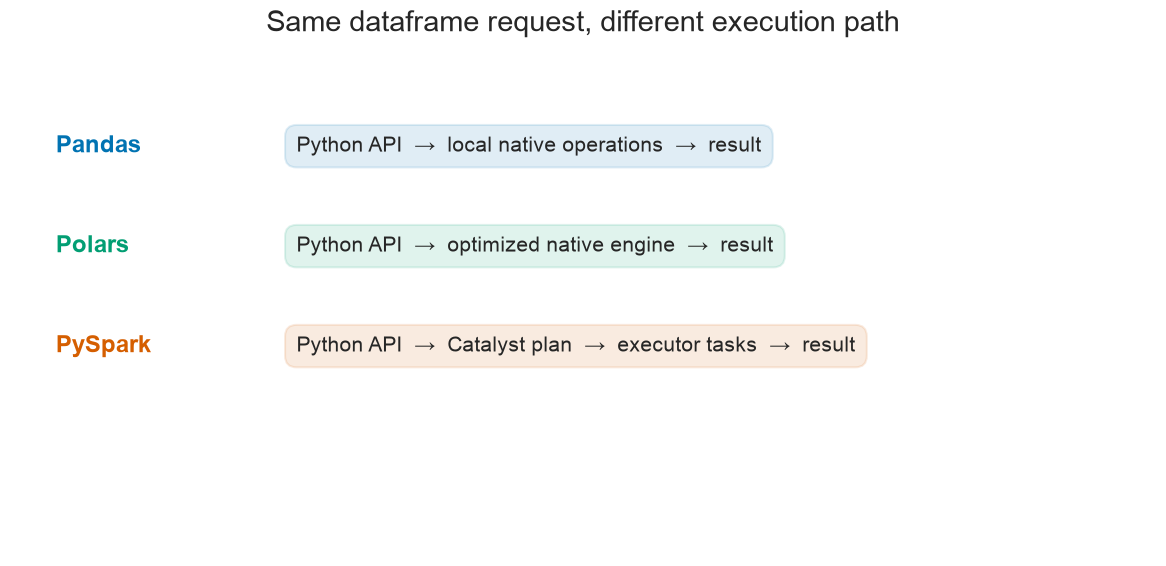

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis("off")
paths = [
    ("Pandas", "Python API  →  local native operations  →  result", "Pandas"),
    ("Polars", "Python API  →  optimized native engine  →  result", "Polars Lazy"),
    (
        "PySpark",
        "Python API  →  Catalyst plan  →  executor tasks  →  result",
        "PySpark",
    ),
]
for y, (framework, path, color_key) in zip([0.82, 0.62, 0.42, 0.22], paths):
    color = FRAMEWORK_COLORS[color_key]
    ax.text(0.04, y, framework, fontsize=17, weight="bold", color=color, va="center")
    ax.text(
        0.25,
        y,
        path,
        fontsize=15,
        va="center",
        bbox=dict(
            boxstyle="round,pad=.55", facecolor=color, alpha=0.12, edgecolor=color
        ),
    )
ax.set_title("Same dataframe request, different execution path", fontsize=21, pad=18)
plt.tight_layout()
plt.show()

## 7. Which framework should I use?

Before revealing the guide, ask the room to choose an engine for each case:

1. Interactive exploration of a 5 GB file with an established Python analytics stack.
2. A repeated 100 GB analytical pipeline that must run efficiently on one strong machine.
3. A multi-terabyte scheduled job that must scale beyond one machine.

<details>
<summary><strong>Reveal the simplified guide</strong></summary>

| Tool | Execution mental model | Good fit |
|---|---|---|
| **Pandas** | Direct local dataframe operations | Exploration and small/medium local data |
| **Polars** | Parallel, optimized local engine | Analytical pipelines on one machine |
| **PySpark** | Optimized distributed task engine | Data processing that must scale across machines |

Likely answers: **Pandas**, **Polars**, and **PySpark**, respectively.

</details>

This is intentionally simplified. Team skills, ecosystem, deployment, and workload shape matter too.

## 8. Takeaways

```text
                SAME THREE QUERY IDEAS

          filter / group / aggregate / join / sort
                            │
           ┌────────────────┼────────────────┐
           ▼                ▼                ▼
        Pandas            Polars           Spark
           │                │                │
      eager local     native engine      lazy distributed
       execution       + optimizer         planning
```

> **Similar dataframe code does not imply similar execution.**

1. Pandas, Polars, and Spark express the same core table operations.
2. Python may be an interface while a native or distributed engine does the expensive work.
3. Compare tools by asking: **Where does work run? When does it run? How is it optimized?**

In [17]:
# Release the local Spark session after the demo.
if spark is not None:
    spark.stop()

In [ ]:
# l1 = [1, 2, 2, 3, 4, 5]

# for item in l1:
#     if item == 2:
#         l1.remove(item)
    
# print(l1)

